# Отклик на кредитный оффер — Альфа-Банк × МФТИ

**Задача:** предсказать вероятность того, что корпоративный клиент согласится на предложенные условия кредитного продукта.

**Метрика:** ROC-AUC

**Подход:**
- Feature engineering на основе бизнес-логики
- CatBoost с 5-fold Stratified CV
- Финальная модель обучена на всём трейне

**Результат на лидерборде:** 75.808

## 1. Импорты и загрузка данных

In [4]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.2 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, RocCurveDisplay
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

In [7]:
train = pd.read_csv('/content/drive/MyDrive/train_apps.csv')
test  = pd.read_csv('/content/drive/MyDrive/test_apps.csv')

print(f'Train: {train.shape}')
print(f'Test:  {test.shape}')

Train: (145241, 28)
Test:  (36311, 27)


## 2. Разведочный анализ данных (EDA)

In [8]:
train.head()

,front_id,decision_day,loan_amount_last,overdraft_limit_min,overdraft_limit_max,offered_rate,cb_rate,corp_credit_products,sum_deb_ul_90,sum_deb_ul_30,...,overdraft_app_term_max_360,days_from_authperson_registration,fl_hdb_bki_total_active_products,corp_list,count_all_corp_dashboard_events,p75_time_spent_minutes,sum_deb_investment_90,db_group_last,fl_adminarea,target_value
0,127345,2024-02-01,1.339991,-1.847954,-1.586546,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,lombard,NaN,0
1,127209,2024-02-01,-2.808489,-3.155914,-2.618329,1.774424,-0.400695,0.842771,NaN,NaN,...,NaN,NaN,NaN,-0.862289,-3.400318,-0.780786,NaN,inn_scoring,NaN,0
2,272776,2024-02-01,2.185431,3.167063,2.369547,-0.709770,-0.400695,0.000000,0.834373,4.897257,...,NaN,NaN,NaN,1.168810,3.015012,0.554064,NaN,NaN,NaN,0
3,127210,2024-02-01,-1.468500,-2.595950,-2.176602,1.774424,-0.400695,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
4,164500,2024-02-01,0.845440,4.559196,3.467730,-2.484194,-0.400695,0.000000,-0.518122,-3.435251,...,NaN,1.067447,NaN,1.022327,1.506380,0.190096,NaN,NaN,NaN,0


In [9]:
# Дисбаланс классов
target_counts = train['target_value'].value_counts()
print('Распределение целевой переменной:')
print(target_counts)
print(f'\nДоля положительных: {target_counts[1] / len(train):.3f} ({target_counts[1]} из {len(train)})')

Распределение целевой переменной:
target_value
0    136395
1      8846
Name: count, dtype: int64

Доля положительных: 0.061 (8846 из 145241)


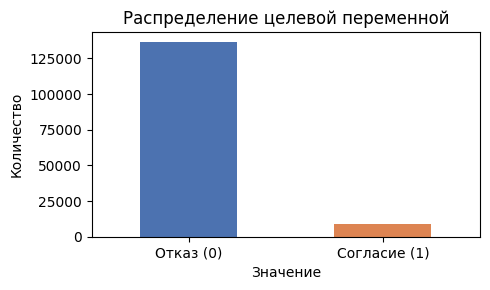

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
train['target_value'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Распределение целевой переменной')
ax.set_xlabel('Значение')
ax.set_ylabel('Количество')
ax.set_xticklabels(['Отказ (0)', 'Согласие (1)'], rotation=0)
plt.tight_layout()
plt.show()

In [11]:
# Пропуски
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(1)
missing_df = pd.DataFrame({'count': missing, 'pct': missing_pct})
print('Признаки с пропусками:')
print(missing_df[missing_df['count'] > 0].sort_values('pct', ascending=False))

Признаки с пропусками:
                                    count   pct
overdraft_app_term_max_360         139732  96.2
loan_rev_max_start_non_fin         132635  91.3
sum_deb_investment_90              128697  88.6
loan_rev_min_start_fin             124706  85.9
days_from_authperson_registration   78473  54.0
sum_deb_ul_30                       61453  42.3
app_term_mean_360                   55883  38.5
db_group_last                       55883  38.5
sum_deb_ul_90                       54111  37.3
corp_credit_products                51188  35.2
p75_time_spent_minutes              51188  35.2
corp_list                           51188  35.2
count_all_corp_dashboard_events     51188  35.2
fl_adminarea                        43310  29.8
balance_rur_amt_30_min              34826  24.0
cnt_deb_ul_ip_30                    33373  23.0
cnt_deb_loan_90                     31458  21.7
cnt_cred_loan_90                    31458  21.7
cnt_deb_ul_ip_90                    30305  20.9
fl_hdb_bki_total_

In [12]:
# Временной разрез: train vs test
train['decision_day'] = pd.to_datetime(train['decision_day'])
test['decision_day']  = pd.to_datetime(test['decision_day'])

print(f'Train: {train["decision_day"].min().date()} — {train["decision_day"].max().date()}')
print(f'Test:  {test["decision_day"].min().date()} — {test["decision_day"].max().date()}')
print('\nТест полностью в будущем относительно трейна — temporal split.')

Train: 2024-02-01 — 2025-06-05
Test:  2025-06-05 — 2025-12-01

Тест полностью в будущем относительно трейна — temporal split.


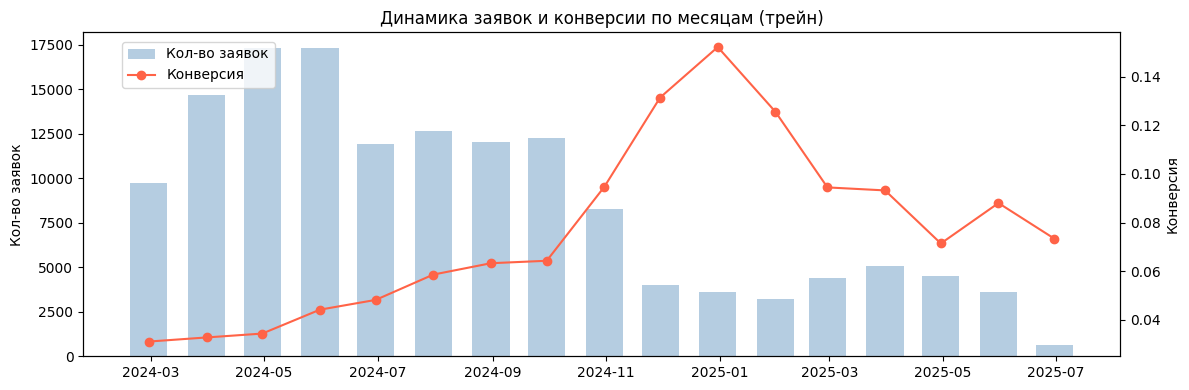

In [13]:
# Конверсия по месяцам
monthly = train.set_index('decision_day').resample('ME')['target_value'].agg(['mean', 'count'])

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.bar(monthly.index, monthly['count'], width=20, alpha=0.4, color='steelblue', label='Кол-во заявок')
ax2.plot(monthly.index, monthly['mean'], color='tomato', marker='o', label='Конверсия')
ax1.set_ylabel('Кол-во заявок')
ax2.set_ylabel('Конверсия')
ax1.set_title('Динамика заявок и конверсии по месяцам (трейн)')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

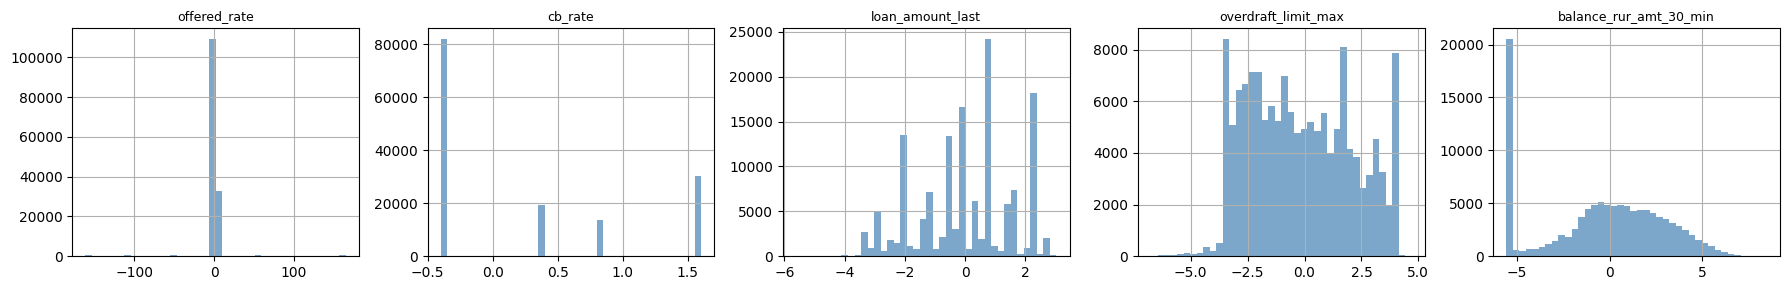

In [14]:
# Распределение ключевых числовых признаков
num_cols = ['offered_rate', 'cb_rate', 'loan_amount_last',
            'overdraft_limit_max', 'balance_rur_amt_30_min']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 3))
for ax, col in zip(axes, num_cols):
    train[col].dropna().hist(bins=40, ax=ax, color='steelblue', alpha=0.7)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

Создаём новые признаки на основе бизнес-логики:
- **Ценовые признаки**: спред и мультипликатор ставки относительно ключевой ЦБ
- **Лимитные признаки**: соотношение запрошенной суммы к одобренному диапазону
- **Активность клиента**: тренд переводов (30 vs 90 дней), вовлечённость в интернет-банк
- **Финансовое состояние**: наличие положительного баланса, инвестиции
- **Профиль клиента**: срок регистрации в банке, логарифм оборотов

In [15]:
def make_features(df):
    df = df.copy()

    # --- Ценовые признаки ---
    # Спред: насколько предложенная ставка выше ключевой
    df['rate_spread'] = df['offered_rate'] - df['cb_rate']
    # Мультипликатор: во сколько раз дороже рынка
    df['rate_to_cb_ratio'] = df['offered_rate'] / (df['cb_rate'].abs() + 1e-9)

    # --- Лимитные признаки ---
    # Насколько запрошенная сумма соответствует одобренному диапазону
    df['loan_to_max_limit']  = df['loan_amount_last'] / (df['overdraft_limit_max'] + 1e-9)
    df['loan_to_min_limit']  = df['loan_amount_last'] / (df['overdraft_limit_min'].abs() + 1e-9)
    df['limit_range']        = df['overdraft_limit_max'] - df['overdraft_limit_min']
    df['dist_to_max_limit']  = df['overdraft_limit_max'] - df['loan_amount_last']
    df['dist_to_min_limit']  = df['loan_amount_last'] - df['overdraft_limit_min']
    # Попадает ли запрошенная сумма в диапазон [min, max]
    df['loan_in_limit_range'] = (
        (df['loan_amount_last'] >= df['overdraft_limit_min']) &
        (df['loan_amount_last'] <= df['overdraft_limit_max'])
    ).astype(float)

    # --- Активность клиента ---
    # Тренд переводов: отношение за 30 дней к 90 дням (>1 = активность растёт)
    df['deb_ul_ratio_30_90'] = df['sum_deb_ul_30'] / (df['sum_deb_ul_90'] + 1e-9)
    # Вовлечённость в интернет-банк: действия × время сессии
    df['digital_engagement'] = (
        df['count_all_corp_dashboard_events'].fillna(0) *
        df['p75_time_spent_minutes'].fillna(0)
    )

    # --- Финансовое состояние ---
    df['has_positive_balance']  = (df['balance_rur_amt_30_min'] > 0).astype(float)
    df['turnover_to_balance']   = df['sum_deb_ul_30'] / (df['balance_rur_amt_30_min'].abs() + 1e-9)
    df['log_sum_deb_ul_30']     = np.log1p(df['sum_deb_ul_30'].clip(lower=0))

    # --- Кредитная активность ---
    df['total_credit_activity_90'] = (
        df['cnt_deb_loan_90'].fillna(0) + df['cnt_cred_loan_90'].fillna(0)
    )

    # --- Профиль клиента ---
    df['reg_years']       = df['days_from_authperson_registration'] / 365
    df['decision_month']  = df['decision_day'].dt.month

    # --- Категориальные: заполняем NaN ---
    df['db_group_last'] = df['db_group_last'].fillna('unknown')
    df['fl_adminarea']  = df['fl_adminarea'].fillna('unknown')

    return df


train = make_features(train)
test  = make_features(test)

CAT_FEATURES = ['db_group_last', 'fl_adminarea']
DROP_COLS    = ['front_id', 'decision_day', 'target_value']
FEATURE_COLS = [c for c in train.columns if c not in DROP_COLS]
TEST_COLS    = [c for c in FEATURE_COLS if c in test.columns]

X      = train[FEATURE_COLS]
y      = train['target_value']
X_test = test[TEST_COLS]

print(f'Итого признаков: {len(FEATURE_COLS)}')
print(FEATURE_COLS)

Итого признаков: 41
['loan_amount_last', 'overdraft_limit_min', 'overdraft_limit_max', 'offered_rate', 'cb_rate', 'corp_credit_products', 'sum_deb_ul_90', 'sum_deb_ul_30', 'cnt_deb_loan_90', 'cnt_deb_ul_ip_90', 'cnt_deb_ul_ip_30', 'balance_rur_amt_30_min', 'cnt_cred_loan_90', 'loan_rev_max_start_non_fin', 'loan_rev_min_start_fin', 'app_term_mean_360', 'overdraft_app_term_max_360', 'days_from_authperson_registration', 'fl_hdb_bki_total_active_products', 'corp_list', 'count_all_corp_dashboard_events', 'p75_time_spent_minutes', 'sum_deb_investment_90', 'db_group_last', 'fl_adminarea', 'rate_spread', 'rate_to_cb_ratio', 'loan_to_max_limit', 'loan_to_min_limit', 'limit_range', 'dist_to_max_limit', 'dist_to_min_limit', 'loan_in_limit_range', 'deb_ul_ratio_30_90', 'digital_engagement', 'has_positive_balance', 'turnover_to_balance', 'log_sum_deb_ul_30', 'total_credit_activity_90', 'reg_years', 'decision_month']


## 4. Обучение модели — CatBoost с 5-fold Stratified CV

**Почему Stratified KFold:** при дисбалансе классов (6.1% положительных) обычный KFold может случайно распределить большинство позитивных примеров в один фолд. Stratified гарантирует одинаковое соотношение классов в каждом фолде.

**Почему CatBoost:** нативная обработка категориальных признаков и пропусков, устойчивость к переобучению за счёт ordered boosting.

In [16]:
skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_preds  = np.zeros(len(X))
test_preds = np.zeros(len(X_test))
fold_aucs  = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = CatBoostClassifier(
        iterations       = 280,
        learning_rate    = 0.05,
        depth            = 7,
        l2_leaf_reg      = 5,
        subsample        = 0.8,
        colsample_bylevel= 0.8,
        cat_features     = CAT_FEATURES,
        eval_metric      = 'AUC',
        early_stopping_rounds = 50,
        random_seed      = SEED,
        verbose          = False,
    )
    model.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)

    oof_preds[val_idx]  = model.predict_proba(X_val)[:, 1]
    test_preds         += model.predict_proba(X_test)[:, 1] / 5

    fold_auc = roc_auc_score(y_val, oof_preds[val_idx])
    fold_aucs.append(fold_auc)
    print(f'Fold {fold + 1}  AUC: {fold_auc:.4f}  |  best_iter: {model.best_iteration_}')

oof_auc = roc_auc_score(y, oof_preds)
print(f'\nOOF AUC: {oof_auc:.4f}  (std: {np.std(fold_aucs):.4f})')

Fold 1  AUC: 0.8273  |  best_iter: 279
Fold 2  AUC: 0.8303  |  best_iter: 279
Fold 3  AUC: 0.8400  |  best_iter: 279
Fold 4  AUC: 0.8347  |  best_iter: 279
Fold 5  AUC: 0.8250  |  best_iter: 278

OOF AUC: 0.8314  (std: 0.0054)


## 5. Анализ результатов

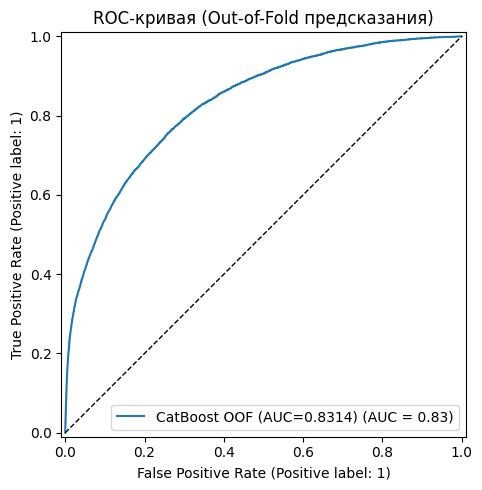

In [17]:
# ROC-кривая на OOF
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y, oof_preds, ax=ax, name=f'CatBoost OOF (AUC={oof_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_title('ROC-кривая (Out-of-Fold предсказания)')
plt.tight_layout()
plt.show()

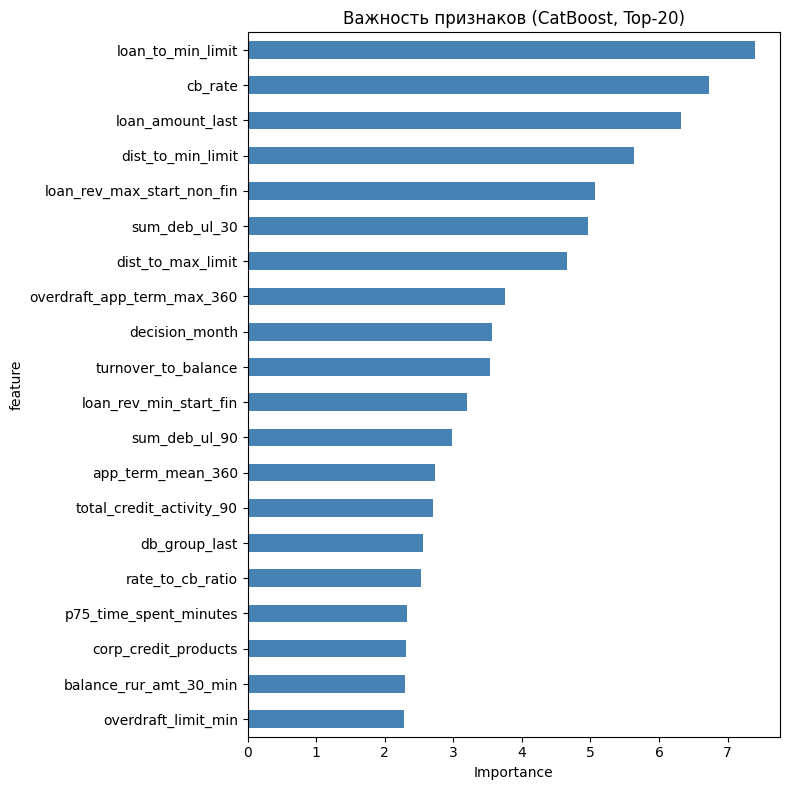

In [18]:
# Feature importance
fi = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'importance': model.get_feature_importance(),
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
fi.head(20).sort_values('importance').plot(
    kind='barh', x='feature', y='importance', ax=ax,
    color='steelblue', legend=False
)
ax.set_title('Важность признаков (CatBoost, Top-20)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

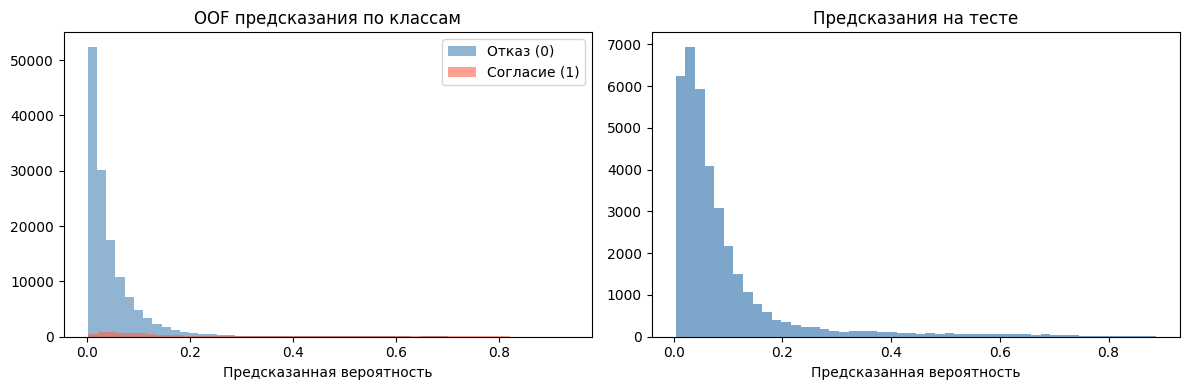

In [19]:
# Распределение предсказаний
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# OOF — разбивка по классам
axes[0].hist(oof_preds[y == 0], bins=50, alpha=0.6, label='Отказ (0)', color='steelblue')
axes[0].hist(oof_preds[y == 1], bins=50, alpha=0.6, label='Согласие (1)', color='tomato')
axes[0].set_title('OOF предсказания по классам')
axes[0].set_xlabel('Предсказанная вероятность')
axes[0].legend()

# Тест
axes[1].hist(test_preds, bins=50, color='steelblue', alpha=0.7)
axes[1].set_title('Предсказания на тесте')
axes[1].set_xlabel('Предсказанная вероятность')

plt.tight_layout()
plt.show()

## 6. Финальная модель и сабмит

Обучаем финальную модель на **всём трейне** с количеством итераций из CV.

In [20]:
model_final = CatBoostClassifier(
    iterations        = 280,
    learning_rate     = 0.05,
    depth             = 7,
    l2_leaf_reg       = 5,
    subsample         = 0.8,
    colsample_bylevel = 0.8,
    cat_features      = CAT_FEATURES,
    random_seed       = SEED,
    verbose           = False,
)
model_final.fit(X, y)
final_preds = model_final.predict_proba(X_test)[:, 1]

print('Финальная модель обучена.')
print(f'Предсказания: min={final_preds.min():.4f}, max={final_preds.max():.4f}, mean={final_preds.mean():.4f}')

Финальная модель обучена.
Предсказания: min=0.0032, max=0.9157, mean=0.0917


In [21]:
submission = pd.DataFrame({
    'front_id':     test['front_id'].values,
    'target_value': final_preds,
})

# Проверки
assert len(submission) == len(test), 'Размер не совпадает с тестом'
assert submission['target_value'].isna().sum() == 0, 'Есть NaN в предсказаниях'
assert (submission['target_value'] >= 0).all() and (submission['target_value'] <= 1).all(), 'Вероятности вне [0, 1]'
assert submission['front_id'].duplicated().sum() == 0, 'Дубликаты front_id'

submission.to_csv('submission.csv', index=False)

print('Сабмит сохранён: submission.csv')
print(f'Строк: {len(submission)}')
submission.head()

Сабмит сохранён: submission.csv
Строк: 36311


,front_id,target_value
0,150378,0.059732
1,194170,0.054158
2,102106,0.013054
3,256199,0.035236
4,253573,0.025187
